In [1]:
!pip install transformers datasets torch scikit-learn -q

In [2]:
# Imports
import pandas as pd
import numpy as np
import torch
from datasets import Dataset
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("/content/Reviews.csv", encoding="utf-8")

df = df[["Text", "Score"]].dropna()
df = df[df["Text"].str.strip() != ""]
df = df.rename(columns={"Text": "review_body", "Score": "star_rating"})
df["star_rating"] = df["star_rating"].astype(int)

def label_from_stars(stars):
    if stars <= 2:
        return 0
    elif stars == 3:
        return 1
    else:
        return 2

df["label"] = df["star_rating"].apply(label_from_stars)

n = min(5000, df["label"].value_counts().min())
df_balanced = pd.concat([
    df[df["label"] == i].sample(n, random_state=42) for i in range(3)
]).sample(frac=1, random_state=42).reset_index(drop=True)

print(df_balanced["label"].value_counts())
print(f"Total : {len(df_balanced)} exemples")

label
0    2487
2    2487
1    2487
Name: count, dtype: int64
Total : 7461 exemples


In [7]:
# Tokenisation
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["review_body"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

dataset = Dataset.from_pandas(df_balanced[["review_body", "label"]])
dataset = dataset.train_test_split(test_size=0.2, seed=42)

train_ds = dataset["train"].map(tokenize, batched=True)
test_ds  = dataset["test"].map(tokenize, batched=True)

train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

print("Train:", len(train_ds), "| Test:", len(test_ds))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/5968 [00:00<?, ? examples/s]

Map:   0%|          | 0/1493 [00:00<?, ? examples/s]

Train: 5968 | Test: 1493


In [8]:
# Modèle
id2label = {0: "negative", 1: "neutral", 2: "positive"}
label2id = {"negative": 0, "neutral": 1, "positive": 2}

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)
print("Modèle chargé")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modèle chargé


In [9]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, preds)}

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=100,
    fp16=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.677603,0.611394,0.734762
2,0.461792,0.626781,0.742130


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=746, training_loss=0.6135788756465145, metrics={'train_runtime': 68.3429, 'train_samples_per_second': 174.649, 'train_steps_per_second': 10.916, 'total_flos': 395289766895616.0, 'train_loss': 0.6135788756465145, 'epoch': 2.0})

              precision    recall  f1-score   support

    negative       0.81      0.66      0.73       505
     neutral       0.61      0.72      0.66       489
    positive       0.81      0.82      0.82       499

    accuracy                           0.73      1493
   macro avg       0.75      0.73      0.74      1493
weighted avg       0.75      0.73      0.74      1493



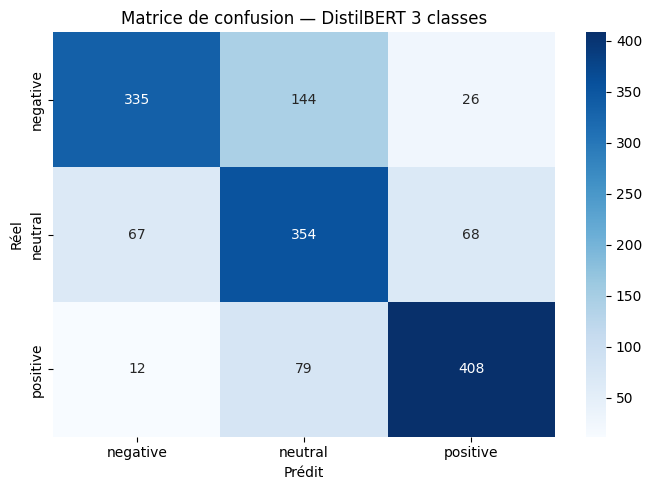

In [10]:
# Évaluation
preds_output = trainer.predict(test_ds)
preds = np.argmax(preds_output.predictions, axis=1)
labels = preds_output.label_ids

print(classification_report(labels, preds, target_names=["negative", "neutral", "positive"]))

cm = confusion_matrix(labels, preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["negative", "neutral", "positive"],
            yticklabels=["negative", "neutral", "positive"])
plt.title("Matrice de confusion — DistilBERT 3 classes")
plt.ylabel("Réel")
plt.xlabel("Prédit")
plt.tight_layout()
plt.show()

In [11]:
# Sauvegarde
model.save_pretrained("sentiment_model_3classes")
tokenizer.save_pretrained("sentiment_model_3classes")

import zipfile, os
with zipfile.ZipFile("sentiment_model_3classes.zip", "w") as z:
    for f in os.listdir("sentiment_model_3classes"):
        z.write(os.path.join("sentiment_model_3classes", f), arcname=f)

print("Modèle sauvegardé → sentiment_model_3classes.zip ✓")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modèle sauvegardé → sentiment_model_3classes.zip ✓
